In [1]:
!pip install underthesea fasttext -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.1 MB/s eta 0:00:00


## 1. Import thư viện

In [2]:
# ==========================
# Standard Libraries
# ==========================
import os
import re
import ast
import gc
import json
import math
import random
import warnings
import pickle

from pathlib import Path
from collections import Counter
from typing import List, Dict, Tuple

# ==========================
# Numerical & Data Processing
# ==========================
import numpy as np
import pandas as pd

# ==========================
# Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Progress Bar
# ==========================
from tqdm.auto import tqdm

# ==========================
# NLP
# ==========================
from underthesea import word_tokenize

# FastText
import fasttext

# ==========================
# Machine Learning
# ==========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

# ==========================
# Deep Learning
# ==========================
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    GlobalAveragePooling1D,
    SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

# ==========================
# Ignore Warnings
# ==========================
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ══════════════════════════════════════════════
# Reproducibility – fix all random seeds
# ══════════════════════════════════════════════
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"All seeds fixed to {SEED}")

All seeds fixed to 42


**Download Stopwords**

In [4]:
!wget https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt

--2026-06-02 08:01:03--  https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20475 (20K) [text/plain]
Saving to: ‘vietnamese-stopwords.txt’

vietnamese-stopword 100%[===================>]  20.00K  --.-KB/s    in 0.002s  

2026-06-02 08:01:04 (12.9 MB/s) - ‘vietnamese-stopwords.txt’ saved [20475/20475]



## 2. Load Dataset

In [5]:
DATA_PATH = "/content/merged_file (1).csv"

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)

df_raw.head()

Raw shape: (6474, 7)


,category,date,title,description,text,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


## 3. Chuẩn hoá cột

In [6]:
def standardize_columns(df_raw: pd.DataFrame):

    lower_map = {c.lower(): c for c in df_raw.columns}

    alias_candidates = {
        "title": ["title"],
        "summary": ["description"],
        "content": ["text"],
        "category": ["category"],
        "author": ["author"],
        "url": ["url"],
        "published_date": ["date"]
    }

    rename_map = {}

    for standard_col, aliases in alias_candidates.items():

        for alias in aliases:

            if alias in lower_map:
                rename_map[lower_map[alias]] = standard_col
                break

    df = df_raw.rename(columns=rename_map).copy()

    required_columns = [
        "title",
        "summary",
        "content",
        "category",
        "author",
        "url",
        "published_date"
    ]

    for col in required_columns:

        if col not in df.columns:
            df[col] = np.nan

    return df


df = standardize_columns(df_raw)

print("Current shape:", df.shape)

df.head()

Current shape: (6474, 7)


,category,published_date,title,summary,content,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


## 4. Làm sạch dữ liệu cơ bản & loại bỏ trùng lặp

In [7]:
def parse_tags(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    if not s or s.lower() == "nan" or s == "[]":
        return []

    if s.startswith("[") and s.endswith("]"):
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list):
                return list(dict.fromkeys([str(v).strip() for v in val if str(v).strip()]))
        except Exception:
            pass

    parts = [p.strip() for p in re.split(r",|;|\|", s) if p.strip()]
    return list(dict.fromkeys(parts))


def clean_basic_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


df["title"] = df["title"].fillna("").astype(str).map(clean_basic_text)
df["summary"] = df["summary"].fillna("").astype(str).map(clean_basic_text)
df["content"] = df["content"].fillna("").astype(str).map(clean_basic_text)
df["category"] = df["category"].fillna("").astype(str).str.strip()

before = len(df)

# Drop duplicate URL nếu có URL
if "url" in df.columns and df["url"].notna().any():
    df = df.drop_duplicates(subset=["url"])

# Drop duplicate title + summary
df = df.drop_duplicates(subset=["title", "summary"])

df = df[df["category"] != ""]

# Drop bài không có content/title đủ dùng
full_text = (df["title"] + " " + df["content"]).str.strip()
df = df[full_text.str.len() > 30].copy()

df = df.reset_index(drop=True)

print(f"Before clean: {before:,}")
print(f"After clean:  {len(df):,}")

eda = pd.DataFrame({
    "n_articles": [len(df)],
    "n_categories": [df["category"].replace("", np.nan).nunique()],
    "missing_content": [(df["content"].str.len() == 0).sum()],
    "missing_summary": [(df["summary"].str.len() == 0).sum()],
    "missing_title": [(df["title"].str.len() == 0).sum()],
    "missing_url": [(df["url"].str.len() == 0).sum()],
})
display(eda)

print("Top categories")
display(df["category"].value_counts().head(20))

Before clean: 6,474
After clean:  6,428


,n_articles,n_categories,missing_content,missing_summary,missing_title,missing_url
0,6428,21,37,8,0,0


Top categories


,count
category,
góc nhìn,1776
bất động sản,1330
xe,965
thời sự,556
giáo dục,531
pháp luật,292
khoa học công nghệ,285
sức khỏe,227
thể thao,180


## 5. Làm sạch các cột văn bản quan trọng

In [8]:
text_columns = ["title", "summary", "content"]

for col in text_columns:

    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .apply(clean_basic_text)
    )

df["category"] = (
    df["category"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["url"] = (
    df["url"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df.head()

,category,published_date,title,summary,content,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


## 6. Loại bỏ bài viết không hợp lệ / quá ngắn

In [9]:
df["combined_text"] = (
    df["title"] + " " +
    df["summary"] + " " +
    df["content"]
)

df["combined_text"] = df["combined_text"].apply(clean_basic_text)

# Remove short articles
df = df[df["combined_text"].str.len() > 30]

df = df.reset_index(drop=True)

print("Final dataset size:", len(df))

Final dataset size: 6428


## 7. Tiền xử lý tiếng Việt

In [10]:
with open("vietnamese-stopwords.txt", "r", encoding="utf-8") as f:
    VI_STOPWORDS = set(
        line.strip()
        for line in f
    )

print("Total stopwords:", len(VI_STOPWORDS))

Total stopwords: 1942


### 7.1 Hàm tokenize tiếng Việt

In [11]:
def vi_tokenize(text):

    return word_tokenize(text, format="text")

### 7.2 Hàm chuẩn hoá văn bản

In [12]:
def normalize_text(text):
    # Basic cleaning
    text = clean_basic_text(text).lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # Remove special characters
    text = re.sub(r"[^0-9a-zA-ZÀ-ỹ_\s]", " ", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return ""
    # Vietnamese tokenization
    text = vi_tokenize(text)
    tokens = []
    for token in text.split():
        token = token.strip()
        # Remove empty token
        if not token:
            continue
        # Remove short token
        if len(token) < 2 and not token.isdigit():
            continue
        # Remove stopwords
        if token in VI_STOPWORDS:
            continue
        tokens.append(token)
    return " ".join(tokens)

### 7.3 Áp dụng tiền xử lý

In [13]:
df["clean_text"] = df["combined_text"].apply(normalize_text)
print("Preprocessing completed.")
df[["combined_text", "clean_text"]].head()

Preprocessing completed.


,combined_text,clean_text
0,Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm H...,giá đất gấp 2 3 hiệu_ứng khu đô_thị lấn biển k...
1,"Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...",trai chuẩn_bị mì tôm_xúc xích đi du_lịch chi_p...
2,"Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...",phân_biệt sốc_nhiệt bệnh hô_hấp tiêu_hóa trẻ g...
3,Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,chi 400 triệu đồng cải_tạo căn_hộ wabi sabi vợ...
4,6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,6 cây_cảnh trồng căn_hộ ánh_sáng hồng môn trúc...


## 8. Lọc các nhãn có quá ít mẫu

In [14]:
MIN_SAMPLES = 10

category_counts = df["category"].value_counts()

valid_categories = category_counts[
    category_counts >= MIN_SAMPLES
].index

df = df[
    df["category"].isin(valid_categories)
].copy()

df.reset_index(drop=True, inplace=True)

print("Remaining classes:", df["category"].nunique())
print("Remaining samples:", len(df))

display(df["category"].value_counts())

Remaining classes: 14
Remaining samples: 6412


,count
category,
góc nhìn,1776
bất động sản,1330
xe,965
thời sự,556
giáo dục,531
pháp luật,292
khoa học công nghệ,285
sức khỏe,227
thể thao,180


## 9. Mã hoá nhãn (Label Encoding)

In [15]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["category"]
)

print("Classes:", label_encoder.classes_)
print()

print(df[["category", "label"]].head())

print("\nLabel Mapping:")

for i, category in enumerate(label_encoder.classes_):
    print(f"{i} --> {category}")

Classes: ['bất động sản' 'du lịch' 'giáo dục' 'giải trí' 'góc nhìn'
 'khoa học công nghệ' 'kinh doanh' 'pháp luật' 'sức khỏe' 'thể thao'
 'thời sự' 'tâm sự' 'xe' 'đời sống']

       category  label
0  bất động sản      0
1        tâm sự     11
2      sức khỏe      8
3  bất động sản      0
4  bất động sản      0

Label Mapping:
0 --> bất động sản
1 --> du lịch
2 --> giáo dục
3 --> giải trí
4 --> góc nhìn
5 --> khoa học công nghệ
6 --> kinh doanh
7 --> pháp luật
8 --> sức khỏe
9 --> thể thao
10 --> thời sự
11 --> tâm sự
12 --> xe
13 --> đời sống


## 10. Khám phá dữ liệu (EDA)

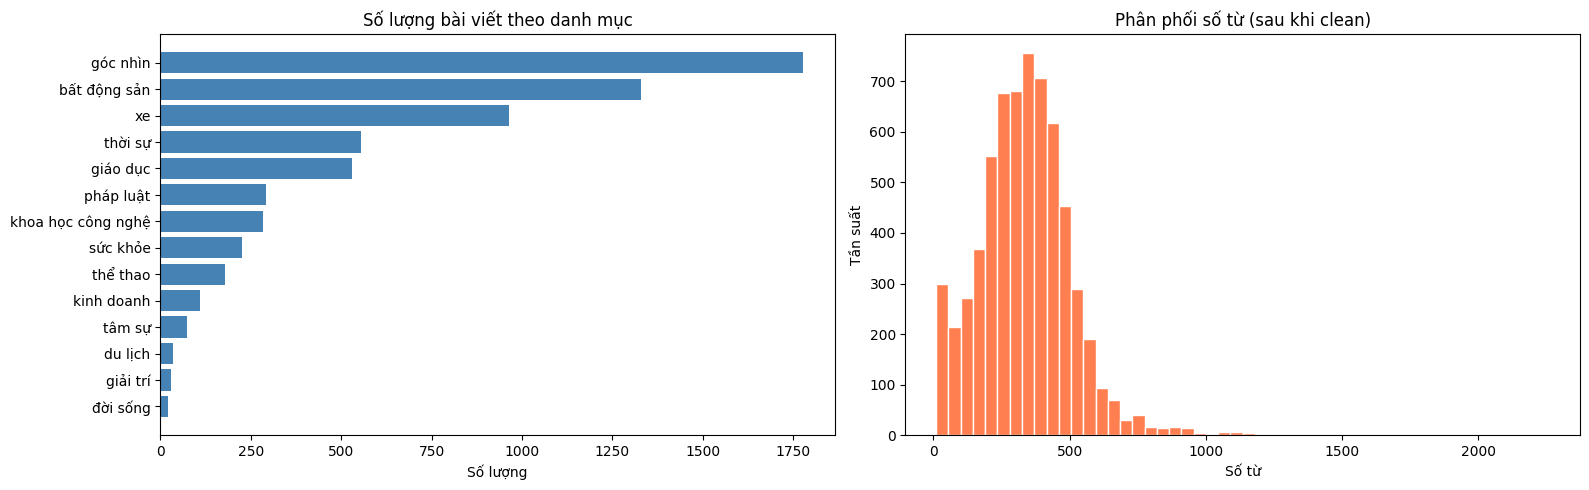


Thống kê độ dài văn bản (số token):
count    6412.000000
mean      337.823144
std       174.796763
min        10.000000
25%       227.000000
50%       334.000000
75%       436.000000
max      2262.000000
Name: clean_text, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Phân phối danh mục ---
cat_counts = df["category"].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[0].set_title("Số lượng bài viết theo danh mục")
axes[0].set_xlabel("Số lượng")

# --- Phân phối độ dài văn bản ---
token_len = df["clean_text"].apply(lambda x: len(x.split()))
axes[1].hist(token_len, bins=50, color="coral", edgecolor="white")
axes[1].set_title("Phân phối số từ (sau khi clean)")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()

print("\nThống kê độ dài văn bản (số token):")
print(token_len.describe())

## 11. Chia tập Train / Test

In [17]:
# Bước 1: tách 80% train, 20% còn lại
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# Bước 2: chia tiếp 20% đó thành 10% val + 10% test
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 5129
Validation: 641
Test: 642


## 12. Huấn luyện mô hình FastText (Word Embeddings)

In [ ]:
# Ghi corpus ra file để FastText đọc
with open("fasttext_corpus.txt", "w", encoding="utf8") as f:
    for text in X_train_text:
        f.write(text + "\n")

print("Corpus saved:", len(X_train_text), "documents")

Corpus saved: 5129 documents


In [ ]:
# Huấn luyện FastText với tham số tối ưu (Chạy 1 lần)
# - model="skipgram": phù hợp cho từ hiếm và OOV (out-of-vocabulary)
# - dim=200: cân bằng giữa chất lượng embedding và tốc độ
# - epoch=20: số lần duyệt corpus đủ để học tốt
# - lr=0.05: learning rate mặc định ổn định cho skipgram
# - wordNgrams=2: nắm bắt cụm từ 2 từ liên tiếp (e.g., "bất_động_sản")
# - minCount=2: bỏ từ xuất hiện < 2 lần (giảm nhiễu)
# - minn=2, maxn=5: subword n-gram bắt được biến thể hình thái học
fasttext_model = fasttext.train_unsupervised(
    "fasttext_corpus.txt",
    model="skipgram",
    dim=200,
    epoch=20,
    lr=0.05,
    wordNgrams=2,
    minCount=2,
    minn=2,
    maxn=5,
    thread=4
)

print("FastText training complete.")
print("Vocabulary size:", len(fasttext_model.words))

FastText training complete.
Vocabulary size: 31267


In [18]:
# Load lại file FastText đã train ()
fasttext_model = fasttext.load_model(
    "/content/fasttext_model.bin"
)

print("FastText model loaded.")

FastText model loaded.


In [19]:
# Kiểm tra embedding vector
vec = fasttext_model.get_word_vector("bóng_đá")
print("Vector dim:", vec.shape)
print("Sample vector:", vec[:5])

Vector dim: (200,)
Sample vector: [-0.07767719 -0.10077911  0.473924    0.10048681 -0.12386297]


## 13. Keras Tokenizer – Xây dựng từ điển

In [20]:
# MAX_WORDS: giữ 30000 từ phổ biến nhất (dữ liệu ~6k docs, không cần quá lớn)
MAX_WORDS = 30000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<UNK>"
)

tokenizer.fit_on_texts(X_train_text)

print("Vocab size (raw):", len(tokenizer.word_index))
print("Effective vocab (MAX_WORDS):", MAX_WORDS)

Vocab size (raw): 21117
Effective vocab (MAX_WORDS): 30000


## 14. Chuyển văn bản thành chuỗi số (Text → Sequences)

In [21]:
# Chuyển văn bản -> sequence

X_train_seq = tokenizer.texts_to_sequences(X_train_text)

X_val_seq = tokenizer.texts_to_sequences(X_val_text)

X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Thống kê độ dài sequence trên tập train
seq_lens = [len(seq) for seq in X_train_seq]

print("Sequence length statistics (Train Set)")
display(pd.Series(seq_lens).describe())

# Percentiles để chọn MAX_LEN hợp lý
print("\nPercentiles:")
print("90% :", np.percentile(seq_lens, 90))
print("95% :", np.percentile(seq_lens, 95))
print("99% :", np.percentile(seq_lens, 99))

Sequence length statistics (Train Set)


,0
count,5129.000000
mean,537.917138
std,283.502994
min,15.000000
25%,350.000000
50%,529.000000
75%,708.000000
max,3183.000000



Percentiles:
90% : 859.1999999999998
95% : 969.5999999999995
99% : 1362.7200000000003


## 15. Padding chuỗi

In [22]:
lengths = df["clean_text"].apply(lambda x: len(x.split()))

print("Token length stats (full dataset):")
print(lengths.describe())

# Chọn MAX_LEN = percentile 90 để tránh padding quá nhiều
MAX_LEN = int(lengths.quantile(0.90))
print(f"\nChọn MAX_LEN = {MAX_LEN} (90th percentile)")

Token length stats (full dataset):
count    6412.000000
mean      337.823144
std       174.796763
min        10.000000
25%       227.000000
50%       334.000000
75%       436.000000
max      2262.000000
Name: clean_text, dtype: float64

Chọn MAX_LEN = 531 (90th percentile)


In [23]:
# Padding sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:  ", X_val_pad.shape)
print("X_test_pad shape: ", X_test_pad.shape)

X_train_pad shape: (5129, 531)
X_val_pad shape:   (641, 531)
X_test_pad shape:  (642, 531)


## 16. Xây dựng ma trận Embedding FastText

In [24]:
EMBEDDING_DIM = 200  # Phải khớp với dim khi train FastText

word_index  = tokenizer.word_index
vocab_size  = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

found = 0
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    vec = fasttext_model.get_word_vector(word)
    embedding_matrix[idx] = vec
    found += 1

coverage = found / vocab_size * 100
print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words covered by FastText: {found}/{vocab_size} ({coverage:.1f}%)")

Embedding matrix shape : (21118, 200)
Words covered by FastText: 21117/21118 (100.0%)


## 17. Chuyển nhãn thành One-hot

In [25]:
num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val,   num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print("Number of classes:", num_classes)
print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:  ", y_val_cat.shape)
print("y_test_cat shape: ", y_test_cat.shape)

Number of classes: 14
y_train_cat shape: (5129, 14)
y_val_cat shape:   (641, 14)
y_test_cat shape:  (642, 14)


## 17b. Tính Class Weight – xử lý mất cân bằng dữ liệu

In [26]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)

# Smooth
class_weights_arr = np.sqrt(class_weights_arr)

# Clip
class_weights_arr = np.clip(
    class_weights_arr,
    a_min=0.3,
    a_max=5.0
)

class_weight_dict = {
    i: float(w)
    for i, w in enumerate(class_weights_arr)
}

# Hiển thị kết quả
print("Class weights (sorted by weight ↓):")
print("-" * 60)

for idx in np.argsort(class_weights_arr)[::-1]:
    cat = label_encoder.classes_[idx]
    cnt = int((y_train == idx).sum())

    print(
        f"{cat:<25} "
        f"weight={class_weights_arr[idx]:6.3f} "
        f"(n_train={cnt})"
    )

Class weights (sorted by weight ↓):
------------------------------------------------------------
đời sống                  weight= 4.642 (n_train=17)
giải trí                  weight= 3.907 (n_train=24)
du lịch                   weight= 3.554 (n_train=29)
tâm sự                    weight= 2.513 (n_train=58)
kinh doanh                weight= 2.040 (n_train=88)
thể thao                  weight= 1.595 (n_train=144)
sức khỏe                  weight= 1.423 (n_train=181)
khoa học công nghệ        weight= 1.268 (n_train=228)
pháp luật                 weight= 1.254 (n_train=233)
giáo dục                  weight= 0.928 (n_train=425)
thời sự                   weight= 0.907 (n_train=445)
xe                        weight= 0.689 (n_train=772)
bất động sản              weight= 0.587 (n_train=1064)
góc nhìn                  weight= 0.508 (n_train=1421)


## 18. Hàm tiện ích – Build Model & Run Experiment

In [27]:
def build_model():
    """Kiến trúc FastText + Bidirectional LSTM – dùng chung cho cả 3 thí nghiệm."""
    m = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True
        ),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.2)),
        LSTM(64, dropout=0.2),
        BatchNormalization(),
        Dense(64, activation="relu"),
        Dropout(0.4),
        Dense(num_classes, activation="softmax")
    ])
    return m


def make_callbacks(prefix: str):
    """Callbacks riêng cho mỗi thí nghiệm – mỗi thí nghiệm lưu model vào file riêng."""
    safe_prefix = prefix.replace(" ", "_").replace("–", "-")
    return [
        EarlyStopping(monitor="val_loss", patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=f"best_{safe_prefix}.keras",
                        monitor="val_loss", save_best_only=True,
                        mode="min", verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ]


def run_experiment(name: str, loss_fn, use_class_weight: bool, lr: float = 1e-3) -> dict:
    """
    Chạy một thí nghiệm đầy đủ: build → compile → fit → evaluate → report.

    Parameters
    ----------
    name             : tên thí nghiệm (hiển thị + dùng làm prefix file)
    loss_fn          : hàm loss hoặc chuỗi (e.g. "categorical_crossentropy")
    use_class_weight : True → truyền class_weight_dict vào fit

    Returns
    -------
    dict: accuracy, macro_f1, weighted_f1, macro_precision, macro_recall,
          history, pred, model
    """
    print(f"\n{'='*60}")
    print(f"  THÍ NGHIỆM: {name}")
    print(f"{'='*60}")

    m = build_model()
    m.compile(optimizer=Adam(learning_rate=lr), loss=loss_fn, metrics=["accuracy"])

    cw   = class_weight_dict if use_class_weight else None
    hist = m.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=30,
        batch_size=64,
        class_weight=cw,
        callbacks=make_callbacks(name),
        verbose=1
    )

    _, acc    = m.evaluate(X_test_pad, y_test_cat, verbose=0)
    pred_prob = m.predict(X_test_pad, verbose=0)
    pred      = np.argmax(pred_prob, axis=1)

    macro_f1        = f1_score(y_test, pred, average="macro")
    weighted_f1     = f1_score(y_test, pred, average="weighted")
    macro_precision = precision_score(y_test, pred, average="macro", zero_division=0)
    macro_recall    = recall_score(y_test, pred, average="macro", zero_division=0)

    print(f"\nTest Accuracy      : {acc:.4f}")
    print(f"Macro F1           : {macro_f1:.4f}")
    print(f"Macro Precision    : {macro_precision:.4f}")
    print(f"Macro Recall       : {macro_recall:.4f}")
    print(f"Weighted F1        : {weighted_f1:.4f}")
    print("\n" + classification_report(
        y_test, pred, target_names=label_encoder.classes_, digits=4,
        zero_division=0
    ))

    return {
        "name"            : name,
        "accuracy"        : float(acc),
        "macro_f1"        : float(macro_f1),
        "weighted_f1"     : float(weighted_f1),
        "macro_precision" : float(macro_precision),
        "macro_recall"    : float(macro_recall),
        "history"         : hist,
        "pred"            : pred,
        "model"           : m
    }


print("build_model(), make_callbacks(), run_experiment() – sẵn sàng.")

build_model(), make_callbacks(), run_experiment() – sẵn sàng.


## 19. Định nghĩa Focal Loss (dùng cho Thí nghiệm C)

In [28]:
def focal_loss(gamma: float = 2.0):
    """
    Categorical Focal Loss – FL = -(1-p_t)^gamma * log(p_t)
    gamma=2.0: hard samples (p_t thấp) được khuếch đại, easy samples bị giảm.
    Chỉ dùng ở Thí nghiệm C nếu B chưa đủ cải thiện Macro F1.
    """
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce     = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t    = tf.reduce_sum(y_true * y_pred, axis=-1)
        return tf.reduce_mean(tf.pow(1.0 - p_t, gamma) * ce)
    return loss_fn

print("focal_loss() định nghĩa xong.")

focal_loss() định nghĩa xong.


## 20. Thí nghiệm A – Baseline (CE, không class_weight)

In [29]:
# ── Thí nghiệm A: Baseline ───────────────────────────────────────────────────
# categorical_crossentropy, KHÔNG dùng class_weight
# Đây là mốc so sánh gốc (kết quả đã biết: Acc=85.2%, Macro F1=56.5%)
result_A = run_experiment(
    name="A – Baseline",
    loss_fn="categorical_crossentropy",
    use_class_weight=False,
    lr=1e-3
)


  THÍ NGHIỆM: A – Baseline
Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.3207 - loss: 2.1869 - val_accuracy: 0.3791 - val_loss: 2.1566 - learning_rate: 0.0010
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.4319 - loss: 1.8513 - val_accuracy: 0.3885 - val_loss: 1.9713 - learning_rate: 0.0010
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.4424 - loss: 1.7647 - val_accuracy: 0.4977 - val_loss: 1.6528 - learning_rate: 0.0010
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.4543 - loss: 1.7505 - val_accuracy: 0.3276 - val_loss: 2.0629 - learning_rate: 0.0010
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.4681 - loss: 1.6571 - val_accuracy: 0.4805 - val_loss: 1.7087 - learning_rate: 0.0010
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.4915 - loss: 1.5952 - val_accuracy: 0.5569 - val_loss: 1.5171 - learning_rate: 0.0010
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0

## 21. Thí nghiệm B – CE + Class Weight

In [30]:
# ── Thí nghiệm B: + Class Weight ────────────────────────────────────────────
# categorical_crossentropy + class_weight_dict
# Kỳ vọng: Macro F1 tăng, Recall lớp nhỏ cải thiện
result_B = run_experiment(
    name="B – CE + Class Weight",
    loss_fn="categorical_crossentropy",
    use_class_weight=True,
    lr=3e-4
)


  THÍ NGHIỆM: B – CE + Class Weight
Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.1603 - loss: 2.3403 - val_accuracy: 0.3307 - val_loss: 2.4496 - learning_rate: 3.0000e-04
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.2726 - loss: 2.1026 - val_accuracy: 0.3385 - val_loss: 2.3326 - learning_rate: 3.0000e-04
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.3242 - loss: 2.0142 - val_accuracy: 0.3838 - val_loss: 2.1662 - learning_rate: 3.0000e-04
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.3646 - loss: 1.9365 - val_accuracy: 0.4446 - val_loss: 1.9748 - learning_rate: 3.0000e-04
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.4005 - loss: 1.8480 - val_accuracy: 0.4743 - val_loss: 1.7624 - learning_rate: 3.0000e-04
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.4361 - loss: 1.7989 - val_accuracy: 0.5117 - val_loss: 1.6088 - learning_rate: 3.0000e-04
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━

## 22. Thí nghiệm C – Focal Loss + Class Weight

In [31]:
# ── Thí nghiệm C: + Focal Loss ──────────────────────────────────────────────
# Focal Loss (gamma=2) + class_weight_dict
# Chỉ chạy nếu Macro F1 của B chưa cải thiện đủ so với A
result_C = run_experiment(
    name="C – Focal Loss + Class Weight",
    loss_fn=focal_loss(gamma=2.0),
    use_class_weight=True,
    lr=3e-4
)


  THÍ NGHIỆM: C – Focal Loss + Class Weight
Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.2266 - loss: 1.7539 - val_accuracy: 0.3822 - val_loss: 1.9594 - learning_rate: 3.0000e-04
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.3539 - loss: 1.3877 - val_accuracy: 0.4259 - val_loss: 1.7178 - learning_rate: 3.0000e-04
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.4016 - loss: 1.2722 - val_accuracy: 0.4758 - val_loss: 1.3433 - learning_rate: 3.0000e-04
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.4293 - loss: 1.1875 - val_accuracy: 0.4618 - val_loss: 1.3036 - learning_rate: 3.0000e-04
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.4484 - loss: 1.1430 - val_accuracy: 0.5476 - val_loss: 1.1290 - learning_rate: 3.0000e-04
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.4744 - loss: 1.0847 - val_accuracy: 0.5632 - val_loss: 1.2647 - learning_rate: 3.0000e-04
Epoch 7/30
81/81 ━━━━━━━

## 23. Bảng so sánh kết quả 3 thí nghiệm

In [32]:
# ── Bảng so sánh tự động 3 thí nghiệm ───────────────────────────────────────
results_list = [result_A, result_B, result_C]

df_compare = pd.DataFrame([
    {
        "Thí nghiệm"   : r["name"],
        "Accuracy"     : round(r["accuracy"],         4),
        "Macro F1"     : round(r["macro_f1"],         4),
        "Macro Prec."  : round(r["macro_precision"],  4),
        "Macro Recall" : round(r["macro_recall"],     4),
        "Weighted F1"  : round(r["weighted_f1"],      4),
    }
    for r in results_list
]).set_index("Thí nghiệm")

# Tô màu đỏ ô cao nhất trong mỗi cột (axis=0 bắt buộc với Pandas ≥ 2.1)
def highlight_max(s):
    return ["background-color: #dc3545; font-weight: bold"
            if v == s.max() else "" for v in s]

print("=" * 65)
print("        BẢNG SO SÁNH KẾT QUẢ 3 THÍ NGHIỆM")
print("=" * 65)
display(df_compare.style.apply(highlight_max, axis=0))

# Kết luận tự động
best_f1_name  = df_compare["Macro F1"].idxmax()
best_acc_name = df_compare["Accuracy"].idxmax()
print(f"\n→ Macro F1 cao nhất    : {best_f1_name}  ({df_compare.loc[best_f1_name,  'Macro F1']:.4f})")
print(f"→ Accuracy cao nhất    : {best_acc_name}  ({df_compare.loc[best_acc_name, 'Accuracy']:.4f})")

        BẢNG SO SÁNH KẾT QUẢ 3 THÍ NGHIỆM


,Accuracy,Macro F1,Macro Prec.,Macro Recall,Weighted F1
Thí nghiệm,,,,,
A – Baseline,0.870700,0.633300,0.648300,0.625900,0.858900
B – CE + Class Weight,0.604400,0.373700,0.431800,0.381100,0.576800
C – Focal Loss + Class Weight,0.602800,0.189100,0.319600,0.223100,0.482600



→ Macro F1 cao nhất    : A – Baseline  (0.6333)
→ Accuracy cao nhất    : A – Baseline  (0.8707)


## 24. So sánh Training Curves

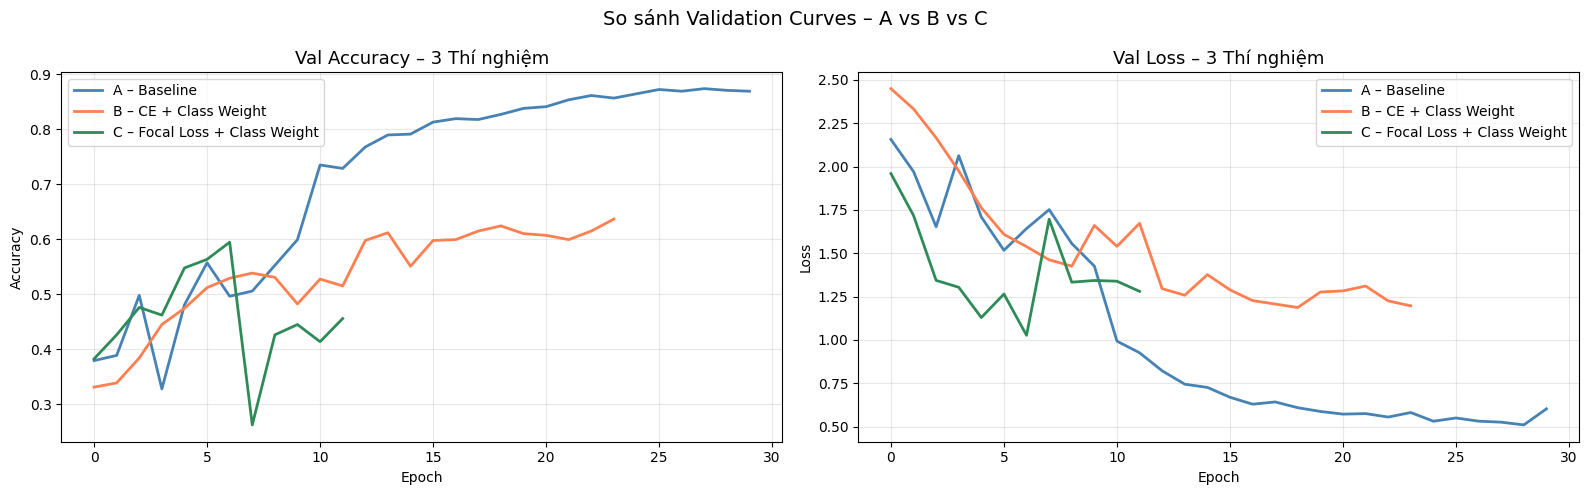

In [33]:
# ── So sánh Training Curves 3 thí nghiệm ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["steelblue", "coral", "seagreen"]
labels = [r["name"] for r in results_list]

for r, color, label in zip(results_list, colors, labels):
    h = r["history"].history
    axes[0].plot(h["val_accuracy"], color=color, label=label, linewidth=2)
    axes[1].plot(h["val_loss"],     color=color, label=label, linewidth=2)

axes[0].set_title("Val Accuracy – 3 Thí nghiệm", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title("Val Loss – 3 Thí nghiệm", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("So sánh Validation Curves – A vs B vs C", fontsize=14)
plt.tight_layout()
plt.show()

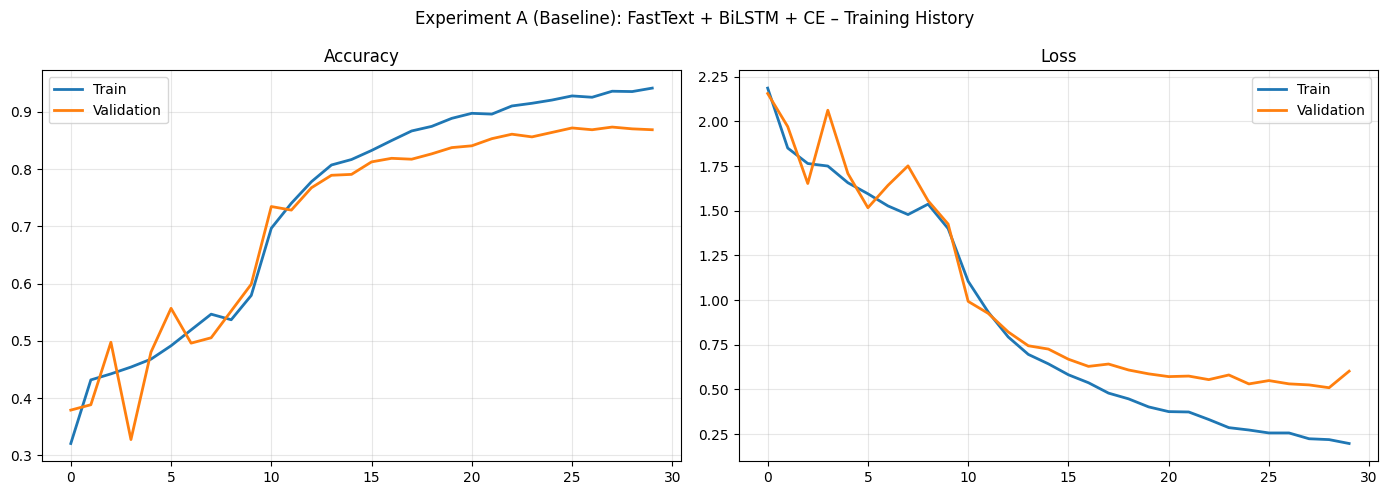

In [41]:
# Chọn A
history_best = result_A["history"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_best.history["accuracy"], label="Train", lw=2)
axes[0].plot(history_best.history["val_accuracy"], label="Validation", lw=2)
axes[0].set_title("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_best.history["loss"], label="Train", lw=2)
axes[1].plot(history_best.history["val_loss"], label="Validation", lw=2)
axes[1].set_title("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Experiment A (Baseline): FastText + BiLSTM + CE – Training History")
plt.tight_layout()
plt.show()

## 25. Confusion Matrix – Model tốt nhất (Macro F1 cao nhất)

Model tốt nhất (Macro F1): A – Baseline


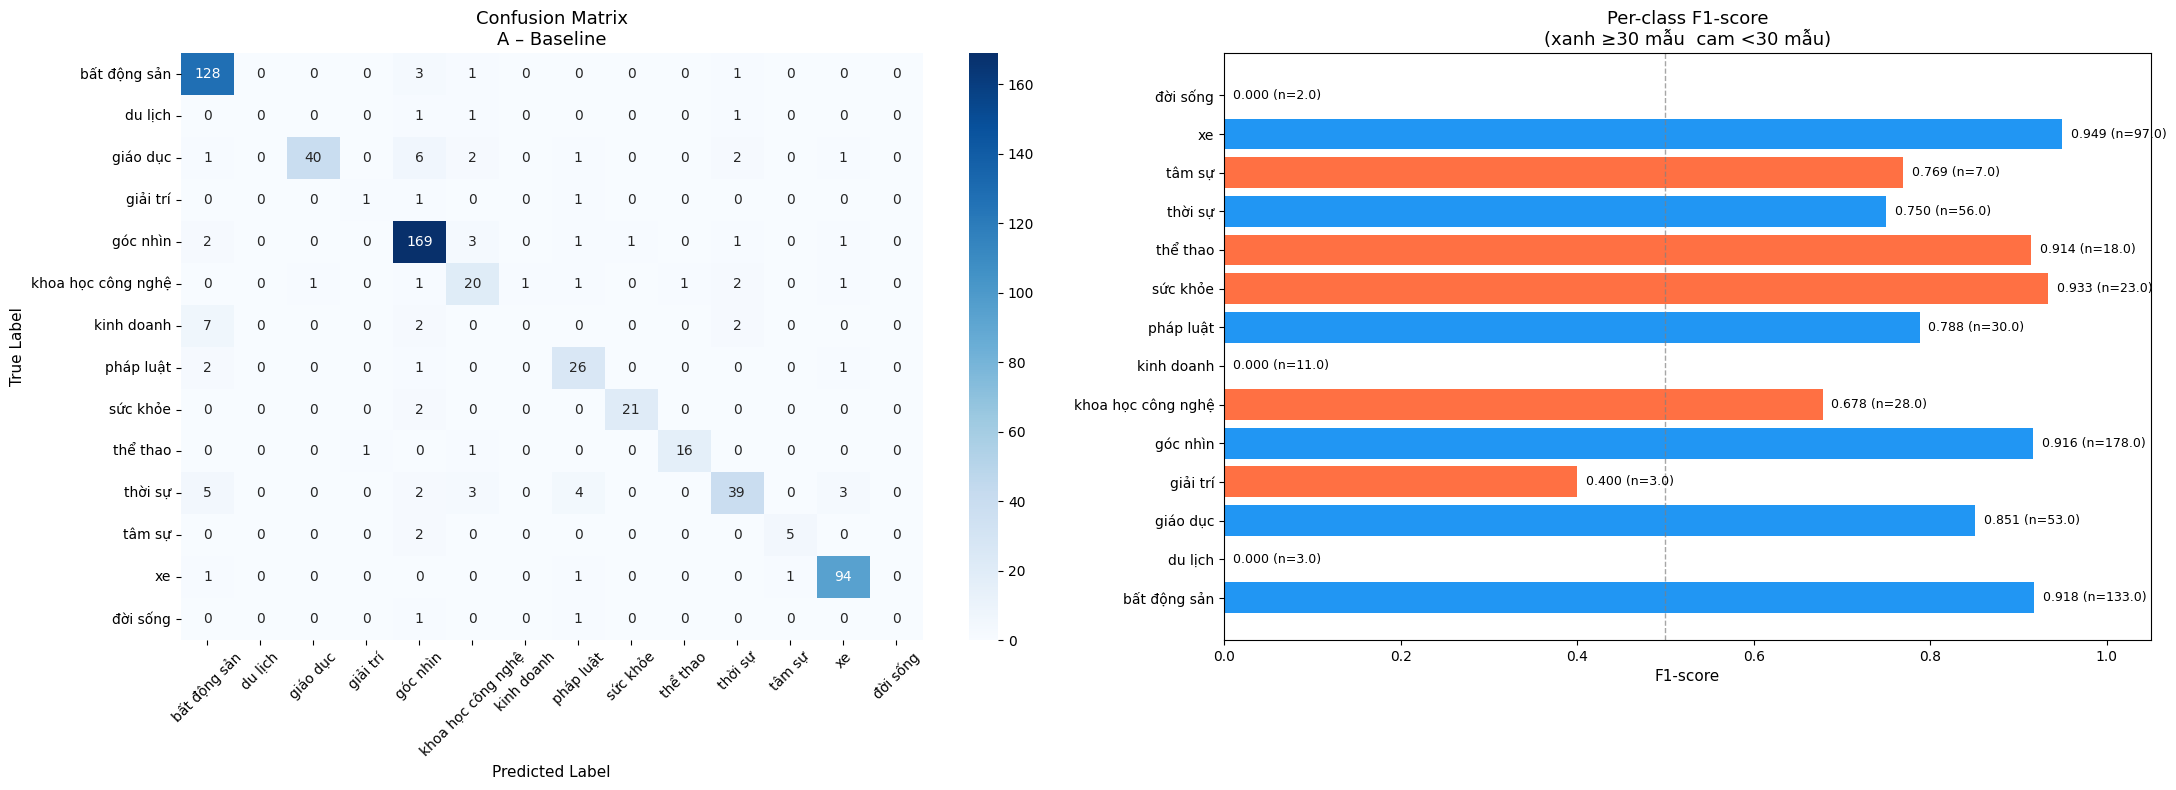

In [35]:
# ── Confusion Matrix + Per-class F1 bar chart ───────────────────────────────
best_result = max(results_list, key=lambda r: r["macro_f1"])
best_pred   = best_result["pred"]
print(f"Model tốt nhất (Macro F1): {best_result['name']}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, best_pred)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0]
)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)
axes[0].set_title(f"Confusion Matrix\n{best_result['name']}", fontsize=13)
axes[0].tick_params(axis="x", rotation=45)

# --- Per-class F1 bar chart ---
report_dict = {}
from sklearn.metrics import classification_report as cr
report_raw = cr(y_test, best_pred, target_names=label_encoder.classes_,
                output_dict=True, zero_division=0)

classes   = label_encoder.classes_
f1_scores = [report_raw[c]["f1-score"] for c in classes]
supports  = [report_raw[c]["support"]  for c in classes]
colors    = ["#2196F3" if s >= 30 else "#FF7043" for s in supports]

axes[1].barh(classes, f1_scores, color=colors)
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("F1-score", fontsize=11)
axes[1].set_title("Per-class F1-score\n(xanh ≥30 mẫu  cam <30 mẫu)", fontsize=13)
axes[1].axvline(x=0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
for i, (f1, sup) in enumerate(zip(f1_scores, supports)):
    axes[1].text(f1 + 0.01, i, f"{f1:.3f} (n={sup})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 26. Lưu mô hình & artifacts (model tốt nhất)

In [40]:
# ── Lưu model tốt nhất & toàn bộ artifacts cần thiết cho inference ─────────
best_model = max(results_list, key=lambda r: r["macro_f1"])["model"]

# Model Keras
best_model.save("fasttext_bilstm_classifier.keras")

# Tokenizer
with open("tokenizer.pkl", "wb") as fh:
    pickle.dump(tokenizer, fh)

# Label encoder
with open("label_encoder.pkl", "wb") as fh:
    pickle.dump(label_encoder, fh)

# Hyperparameters & class weights (needed to reconstruct model for inference)
meta = {
    "MAX_LEN"          : MAX_LEN,
    "MAX_WORDS"        : MAX_WORDS,
    "EMBEDDING_DIM"    : EMBEDDING_DIM,
    "num_classes"      : num_classes,
    "class_weight_dict": class_weight_dict,
    "best_experiment"  : max(results_list, key=lambda r: r["macro_f1"])["name"],
}
with open("model_meta.pkl", "wb") as fh:
    pickle.dump(meta, fh)

print("Artifacts saved:")
print("  fasttext_bilstm_classifier.keras  ← best model (highest Macro F1)")
print("  tokenizer.pkl")
print("  label_encoder.pkl")
print("  model_meta.pkl                    ← MAX_LEN, class weights, config")

Artifacts saved:
  fasttext_bilstm_classifier.keras  ← best model (highest Macro F1)
  tokenizer.pkl
  label_encoder.pkl
  model_meta.pkl                    ← MAX_LEN, class weights, config


## 27. Hàm dự đoán cho bài viết mới (Inference)

In [39]:
# ── Cache the best model once (avoid re-scanning results_list every call) ───
_best_model = max(results_list, key=lambda r: r["macro_f1"])["model"]


def predict_category(text: str, top_k: int = 3) -> list:
    """
    Dự đoán danh mục cho một bài viết tiếng Việt.

    Parameters
    ----------
    text  : str  – văn bản gốc (chưa qua tiền xử lý)
    top_k : int  – số danh mục trả về (theo xác suất giảm dần)

    Returns
    -------
    list of (category, probability) tuples
    """
    cleaned = normalize_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    probs   = _best_model.predict(padded, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(label_encoder.classes_[i], float(probs[i])) for i in top_idx]


def predict_batch(texts: list, top_k: int = 1) -> list:
    """
    Dự đoán hàng loạt bài viết – hiệu quả hơn gọi predict_category() lặp lại.

    Parameters
    ----------
    texts : list[str]  – danh sách văn bản gốc
    top_k : int        – số danh mục trả về cho mỗi văn bản

    Returns
    -------
    list of list of (category, probability) tuples
    """
    cleaned = [normalize_text(t) for t in texts]
    seqs    = tokenizer.texts_to_sequences(cleaned)
    padded  = pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")
    probs   = _best_model.predict(padded, verbose=0)
    results_out = []
    for p in probs:
        top_idx = np.argsort(p)[::-1][:top_k]
        results_out.append([(label_encoder.classes_[i], float(p[i])) for i in top_idx])
    return results_out


# ── Single-text demo ─────────────────────────────────────────────────────────
sample_text = (
    "PGS. TS Nguyễn Tấn Trần Minh Khang, 52 tuổi, giữ chức hiệu trưởng "
    "trường Đại học Công nghệ Thông tin, Đại học Quốc gia TP HCM"
)
preds = predict_category(sample_text, top_k=3)

print(f"Văn bản : {sample_text}")
print("\nTop-3 dự đoán:")
for cat, prob in preds:
    bar = "█" * int(prob * 40)
    print(f"  {cat:<25} {prob:.4f}  {bar}")

# ── Batch demo ───────────────────────────────────────────────────────────────
batch_samples = [
    "Bộ Giáo dục công bố lịch thi tốt nghiệp THPT năm 2026",
    "Manchester City giành chiến thắng 3-0 ở vòng đấu cuối tuần",
    "Giá căn hộ tại TP.HCM tiếp tục tăng trong quý II",
    "Toyota ra mắt mẫu xe hybrid mới với nhiều công nghệ hiện đại",
    "Các bác sĩ cảnh báo nguy cơ đột quỵ ở người trẻ tuổi",
]

batch_preds = predict_batch(batch_samples, top_k=1)

print("\n── Batch Inference ──")
for text, pred_list in zip(batch_samples, batch_preds):
    cat, prob = pred_list[0]
    print(f"[{cat:<20} {prob:.3f}]  {text}")

Văn bản : PGS. TS Nguyễn Tấn Trần Minh Khang, 52 tuổi, giữ chức hiệu trưởng trường Đại học Công nghệ Thông tin, Đại học Quốc gia TP HCM

Top-3 dự đoán:
  giáo dục                  0.9999  ███████████████████████████████████████
  góc nhìn                  0.0000  
  thời sự                   0.0000  

── Batch Inference ──
[giáo dục             0.999]  Bộ Giáo dục công bố lịch thi tốt nghiệp THPT năm 2026
[thể thao             0.424]  Manchester City giành chiến thắng 3-0 ở vòng đấu cuối tuần
[kinh doanh           0.392]  Giá căn hộ tại TP.HCM tiếp tục tăng trong quý II
[xe                   0.988]  Toyota ra mắt mẫu xe hybrid mới với nhiều công nghệ hiện đại
[xe                   0.959]  Các bác sĩ cảnh báo nguy cơ đột quỵ ở người trẻ tuổi
